# Wisconsin breast cancer data set exploration
- https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html
- https://www.slingacademy.com/article/analyzing-the-breast-cancer-dataset-with-scikit-learn/
- https://ucb-stat-159-s22.github.io/hw07-Group26/main.html
- https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

### Alternative way to load WBC dataset:
```python
from sklearn.datasets import load_breast_cancer

wbc = load_breast_cancer(as_frame=True)
print(wbc.DESCR)
```

In [ ]:
# import the dataset from downloaded csv
import pandas as pd
df = pd.read_csv("../data/wisconsin.csv")

print(f"Dataset shape: {df.shape}")
print(f"Info: {df.info()}")
print(df["diagnosis"].value_counts())

Dataset shape: (569, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  p

In [2]:
df.sample(5).T

,505,141,195,259,190
id,915276,869104,875878,88725602,874858
diagnosis,B,M,B,M,M
radius_mean,9.676,16.11,12.91,15.53,14.22
texture_mean,13.14,18.05,16.33,33.56,23.12
perimeter_mean,64.12,105.1,82.53,103.7,94.37
area_mean,272.5,813.0,516.4,744.9,609.9
smoothness_mean,0.1255,0.09721,0.07941,0.1063,0.1075
compactness_mean,0.2204,0.1137,0.05366,0.1639,0.2413
concavity_mean,0.1188,0.09447,0.03873,0.1751,0.1981
concave points_mean,0.07038,0.05943,0.02377,0.08399,0.06618


In [3]:
null_values = df.isnull().values.any()
if null_values:
    print("There are some missing values in data")
else:
    print("There are no missing values in the dataset")

There are some missing values in data


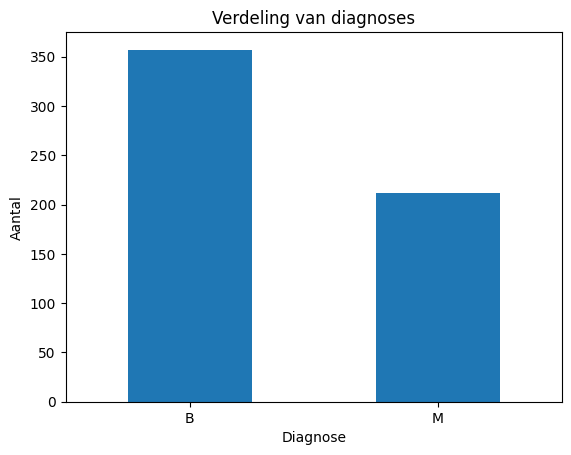

In [4]:
# Verdeling van de diagnoses in een barplot
import matplotlib.pyplot as plt

df['diagnosis'].value_counts().plot(kind='bar')
plt.title('Verdeling van diagnoses')
plt.xlabel('Diagnose')
plt.xticks(rotation=0)
plt.ylabel('Aantal')
plt.show()

In [5]:
# add a column 'target' with binary repr of diagnosis
dft = df.drop(["id", "Unnamed: 32"], axis=1)
dft["target"] = dft["diagnosis"].apply(lambda x: 0 if x == "B" else 1)
dft.sample(5)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,target
527,B,12.34,12.27,78.94,468.5,0.09003,0.06307,0.02958,0.02647,0.1689,0.05808,0.1166,0.4957,0.7714,8.955,0.003681,0.009169,0.008732,0.00574,0.01129,0.001366,13.61,19.27,87.22,564.9,0.1292,0.20740,0.17910,0.10700,0.3110,0.07592,0
52,B,11.94,18.24,75.71,437.6,0.08261,0.04751,0.01972,0.01349,0.1868,0.06110,0.2273,0.6329,1.5200,17.470,0.007210,0.008380,0.013110,0.00800,0.01996,0.002635,13.10,21.33,83.67,527.2,0.1144,0.08906,0.09203,0.06296,0.2785,0.07408,0
515,B,11.34,18.61,72.76,391.2,0.10490,0.08499,0.04302,0.02594,0.1927,0.06211,0.2430,1.0100,1.4910,18.190,0.008577,0.016410,0.020990,0.01107,0.02434,0.001217,12.47,23.03,79.15,478.6,0.1483,0.15740,0.16240,0.08542,0.3060,0.06783,0
451,M,19.59,25.00,127.70,1191.0,0.10320,0.09871,0.16550,0.09063,0.1663,0.05391,0.4674,1.3750,2.9160,56.180,0.011900,0.019290,0.049070,0.01499,0.01641,0.001807,21.44,30.96,139.80,1421.0,0.1528,0.18450,0.39770,0.14660,0.2293,0.06091,1
57,M,14.71,21.59,95.55,656.9,0.11370,0.13650,0.12930,0.08123,0.2027,0.06758,0.4226,1.1500,2.7350,40.090,0.003659,0.028550,0.025720,0.01272,0.01817,0.004108,17.87,30.70,115.70,985.5,0.1368,0.42900,0.35870,0.18340,0.3698,0.10940,1


In [6]:
# correlaties tss de vars
df_corr = dft.drop("diagnosis", axis=1).corr()
df_corr.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,target
count,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000
mean,0.438637,0.261577,0.461766,0.446701,0.362867,0.562987,0.589211,0.576276,0.359918,0.223537,0.458618,0.113197,0.471689,0.435215,0.112296,0.433161,0.383888,0.442706,0.167639,0.296543,0.463534,0.264043,0.486118,0.458907,0.327026,0.488489,0.520861,0.550460,0.307749,0.344980,0.481319
std,0.400925,0.228113,0.391679,0.395421,0.221067,0.219835,0.235320,0.283082,0.198595,0.348098,0.281607,0.240596,0.273506,0.314741,0.271121,0.229566,0.228948,0.200638,0.244168,0.275876,0.395930,0.234937,0.386581,0.387557,0.242193,0.255282,0.255050,0.294494,0.237320,0.288429,0.279975
min,-0.311631,-0.076437,-0.261477,-0.283110,-0.023389,0.046205,0.076218,0.021480,0.071401,-0.311631,0.000111,-0.128215,0.039830,-0.090170,-0.230691,0.143003,0.100241,0.086741,-0.128121,-0.042641,-0.253691,-0.077473,-0.217304,-0.231854,-0.073658,-0.092439,-0.068956,-0.119638,-0.128215,-0.045655,-0.067016
25%,0.155847,0.112107,0.186071,0.147431,0.210199,0.502313,0.449061,0.372203,0.186524,-0.063853,0.234160,-0.078426,0.255315,0.165303,-0.088375,0.241222,0.202724,0.334814,-0.021538,0.066215,0.195755,0.121622,0.231728,0.193862,0.146234,0.375496,0.382842,0.435384,0.143343,0.082540,0.327185
50%,0.413463,0.277830,0.455774,0.390410,0.318943,0.565369,0.670279,0.667454,0.342627,0.334019,0.380585,0.068406,0.418899,0.385100,0.098564,0.356065,0.309429,0.394999,0.134109,0.257584,0.475820,0.248133,0.529408,0.438296,0.227394,0.472468,0.532520,0.547691,0.269493,0.323872,0.548236
75%,0.740039,0.326657,0.758112,0.766324,0.501185,0.673253,0.706248,0.822899,0.455817,0.469360,0.694907,0.226727,0.695168,0.740423,0.321443,0.615060,0.465744,0.579357,0.328894,0.438337,0.781939,0.359838,0.799618,0.780589,0.499390,0.640947,0.661087,0.790495,0.455066,0.564410,0.719506
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


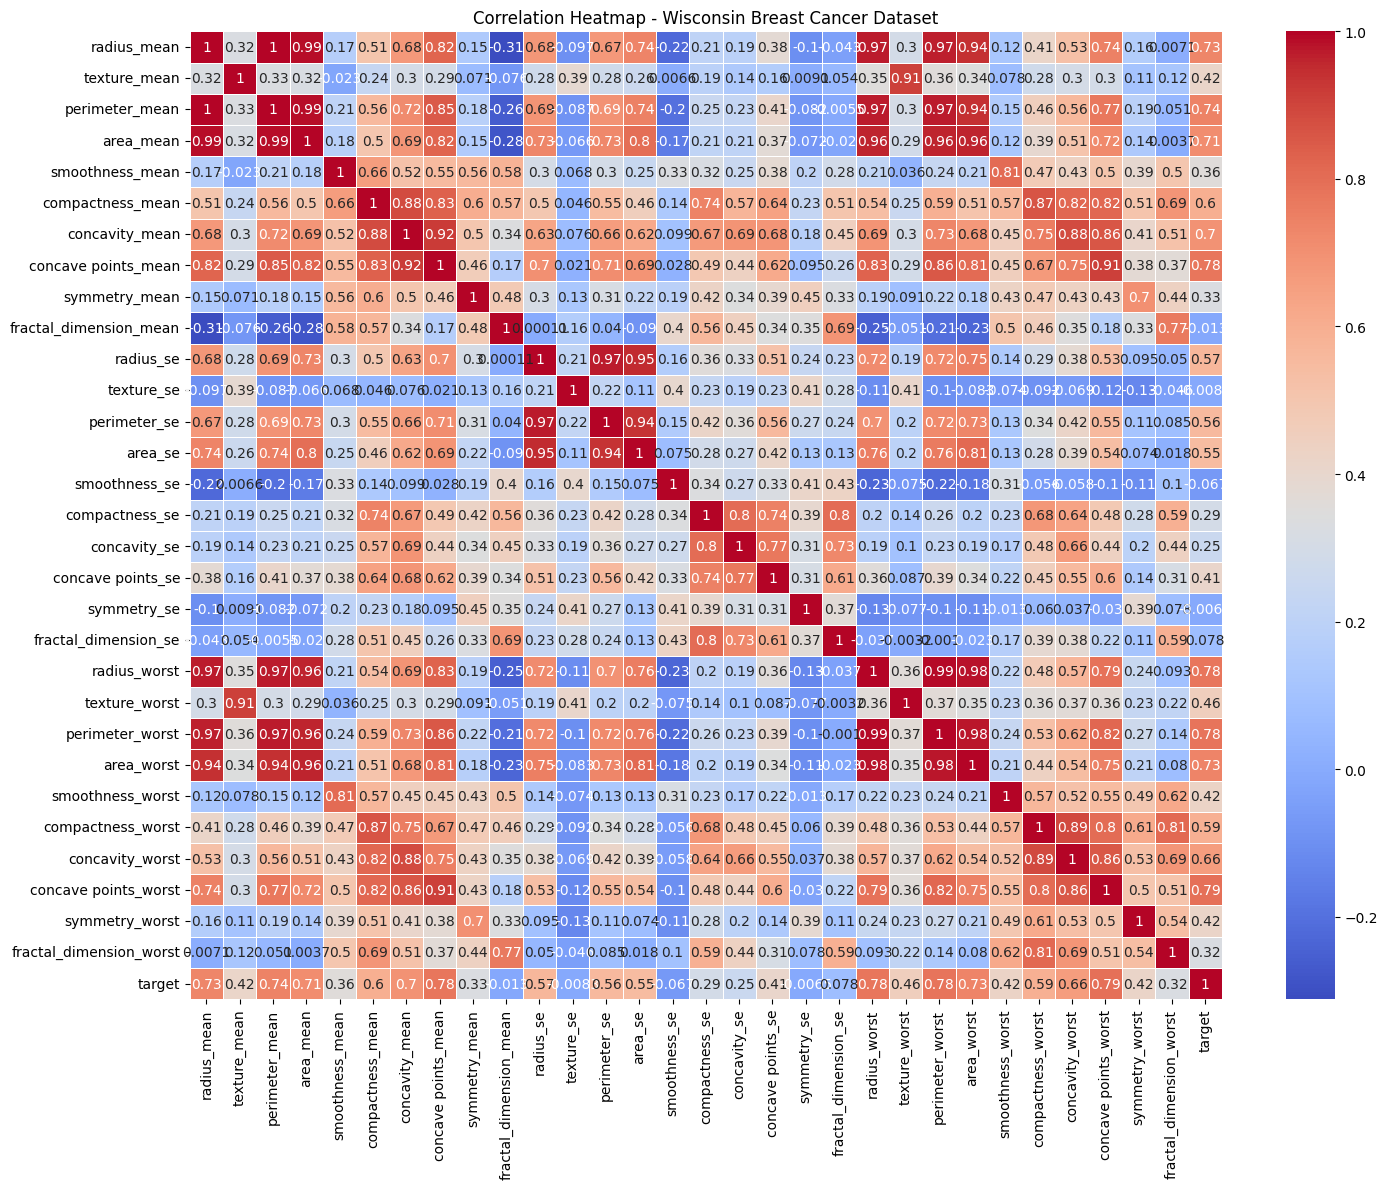

In [7]:
# heatmap van de correlatiematrix:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(
    df_corr,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
    )
plt.title("Correlation Heatmap - Wisconsin Breast Cancer Dataset", fontsize=12)
plt.tight_layout()
plt.show()

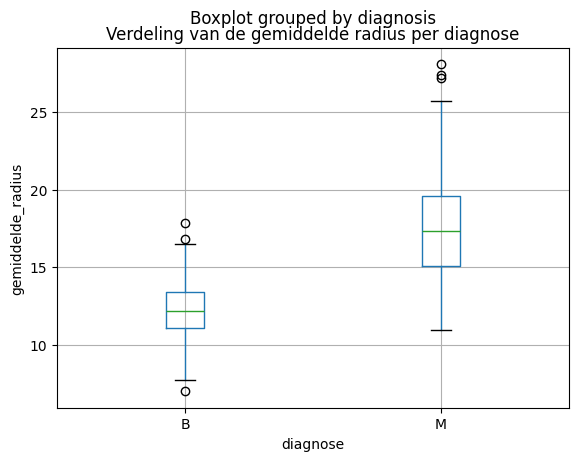

In [8]:
# Boxplot van de gemiddelde radius, opgesplitst per diagnose
df.boxplot(column='radius_mean', by='diagnosis')
plt.title('Verdeling van de gemiddelde radius per diagnose')
plt.xlabel('diagnose')
plt.ylabel('gemiddelde_radius')
plt.show()

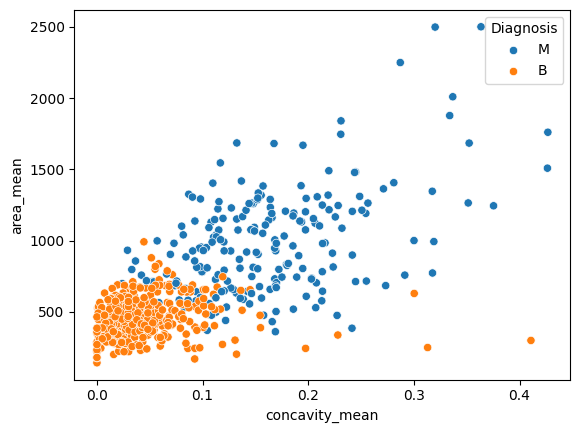

In [9]:
# try visualize distinction between two random variables:
sns.scatterplot(data=df, x="concavity_mean", y="area_mean", hue="diagnosis")
plt.legend(title='Diagnosis')

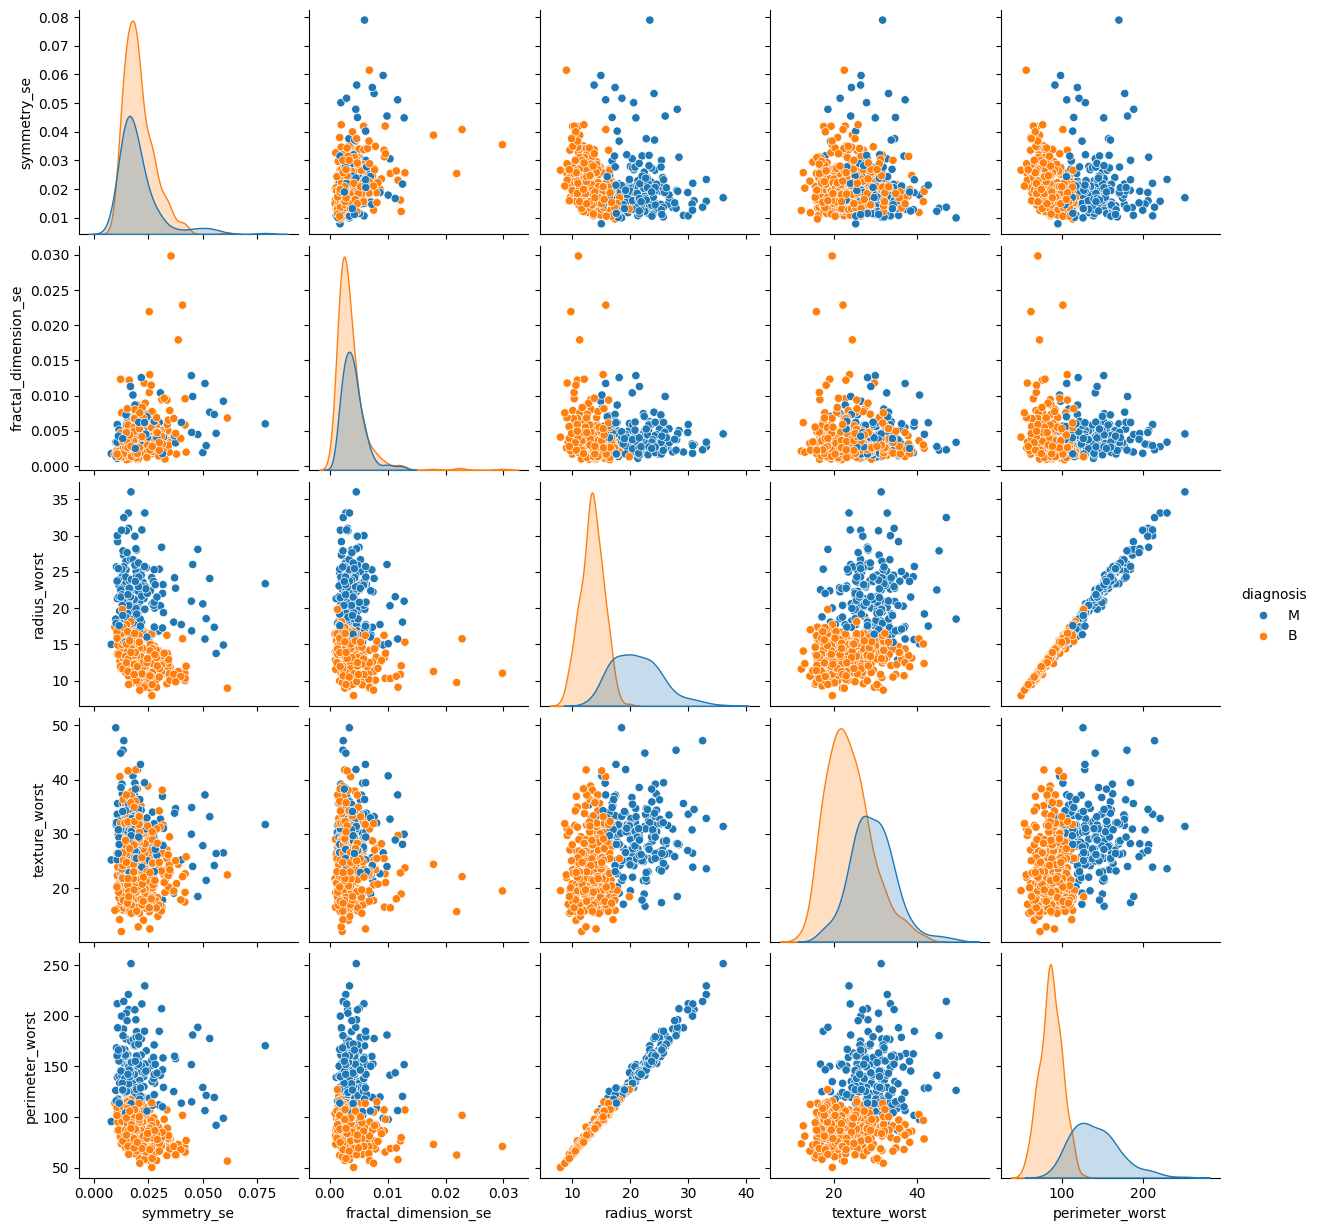

In [10]:
# some scatter plots to split (or not) diff pairs of vars by diagnosis
import seaborn as sns

sns.pairplot(df, vars=df.columns[20:25], hue="diagnosis")
plt.show()

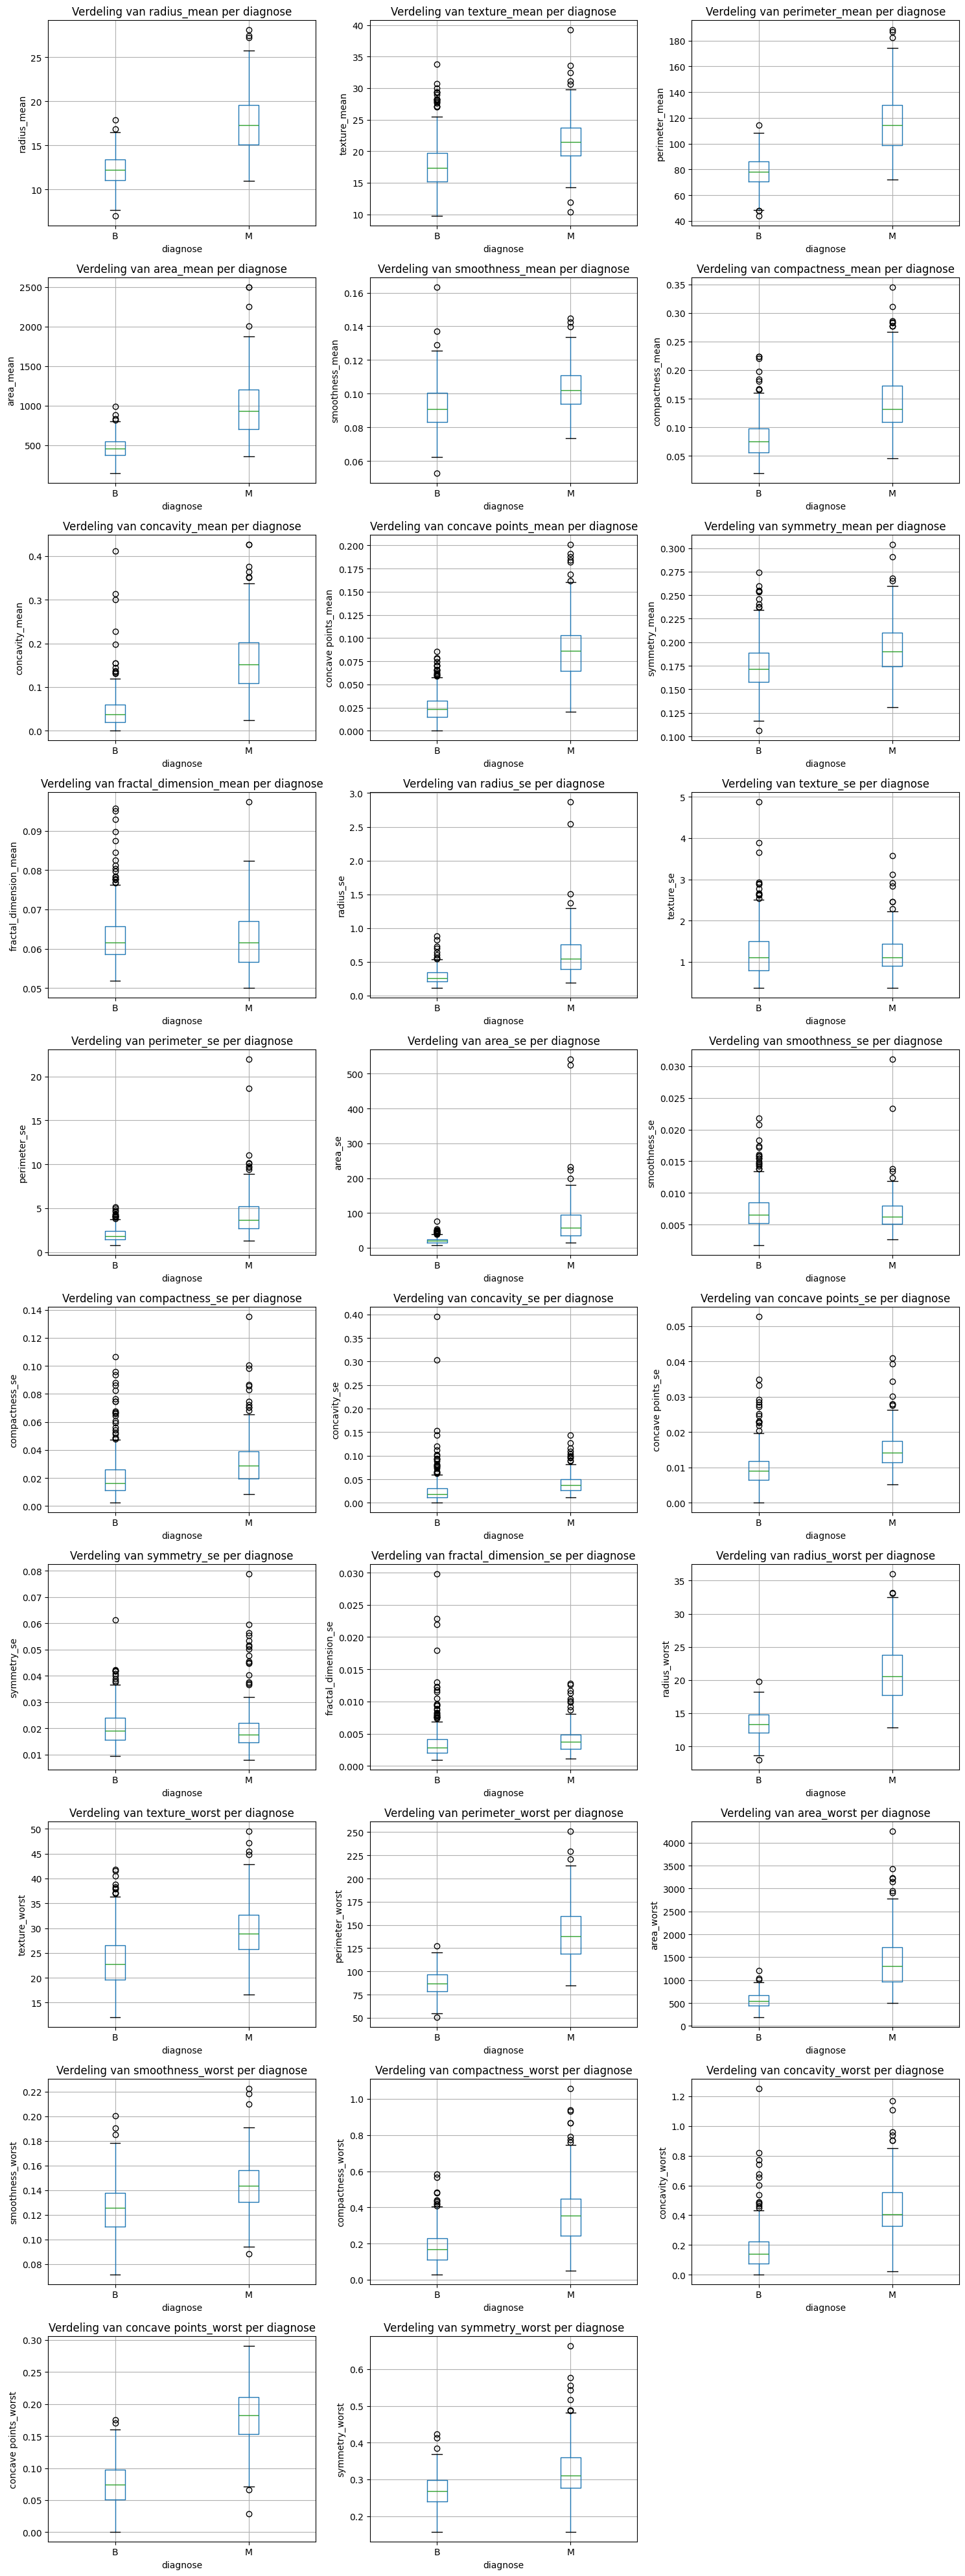

In [11]:
variables_to_plot = dft.columns[1:-2]

fig, axes = plt.subplots(10, 3, figsize=(15, 40))
axes = axes.flatten()  # make indexing easier

for i, var in enumerate(variables_to_plot):
    dft.boxplot(column=var, by='diagnosis', ax=axes[i])
    axes[i].set_title(f"Verdeling van {var} per diagnose")
    axes[i].set_xlabel("diagnose")
    axes[i].set_ylabel(var)

# Remove empty subplots (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("")  # remove automatic pandas title
plt.tight_layout()
plt.show()

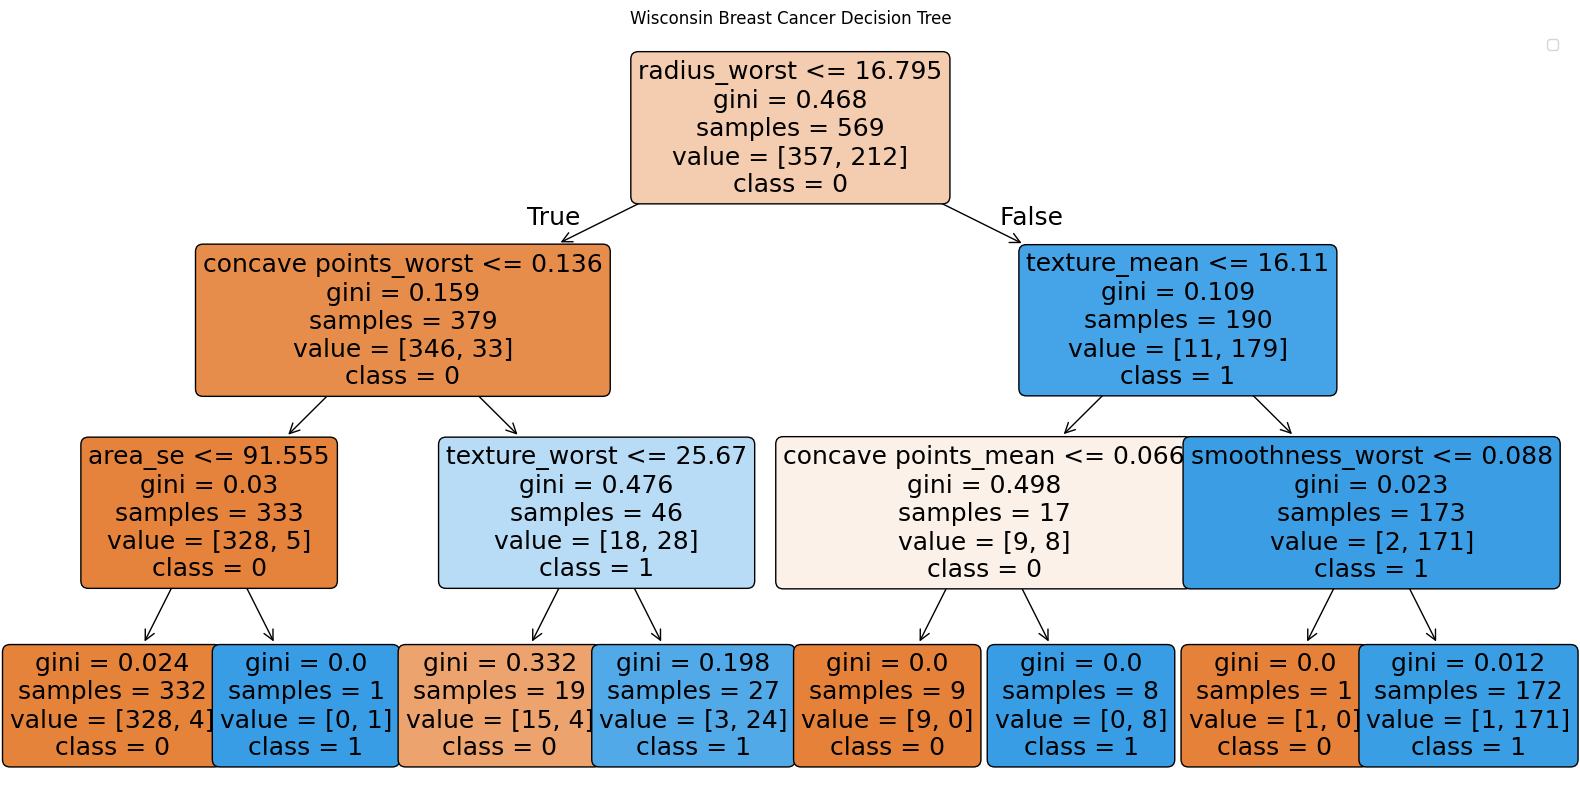

In [12]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
# from sklearn import tree

X = dft.loc[:,"radius_mean":"fractal_dimension_worst"]
y = dft['target']

dtree = DecisionTreeClassifier(criterion='gini',  # standaard
                                max_depth = 3,
                                # ccp_alpha=0.01,    # complexity parameter, vergelijkbaar met cp in R
                                random_state=42)

# dtree = DecisionTreeClassifier(criterion='gini',  # standaard
#                                 max_depth = 3)
dtree = dtree.fit(X, y)

# tree.plot_tree(dtree, feature_names=features)

# Visualiseer de boom
plt.figure(figsize=(20,10))
plot_tree(
    dtree,
    feature_names=X.columns,
    class_names=['0', '1'],
    filled=True,
    rounded=True,
    fontsize=18
)
plt.title("Wisconsin Breast Cancer Decision Tree")
plt.legend(['B', 'M'])
plt.show()

In [13]:
from sklearn.metrics import confusion_matrix

# Accuracy van de decision tree
y_pred_tree = dtree.predict(X)
print(confusion_matrix(y, y_pred_tree))
print(f'Accuracy Decision Tree: {dtree.score(X, y):.2f}')

[[353   4]
 [  8 204]]
Accuracy Decision Tree: 0.98


This seems to be too optimistic.

De accuraatheid op nieuwe data is: 90.35%


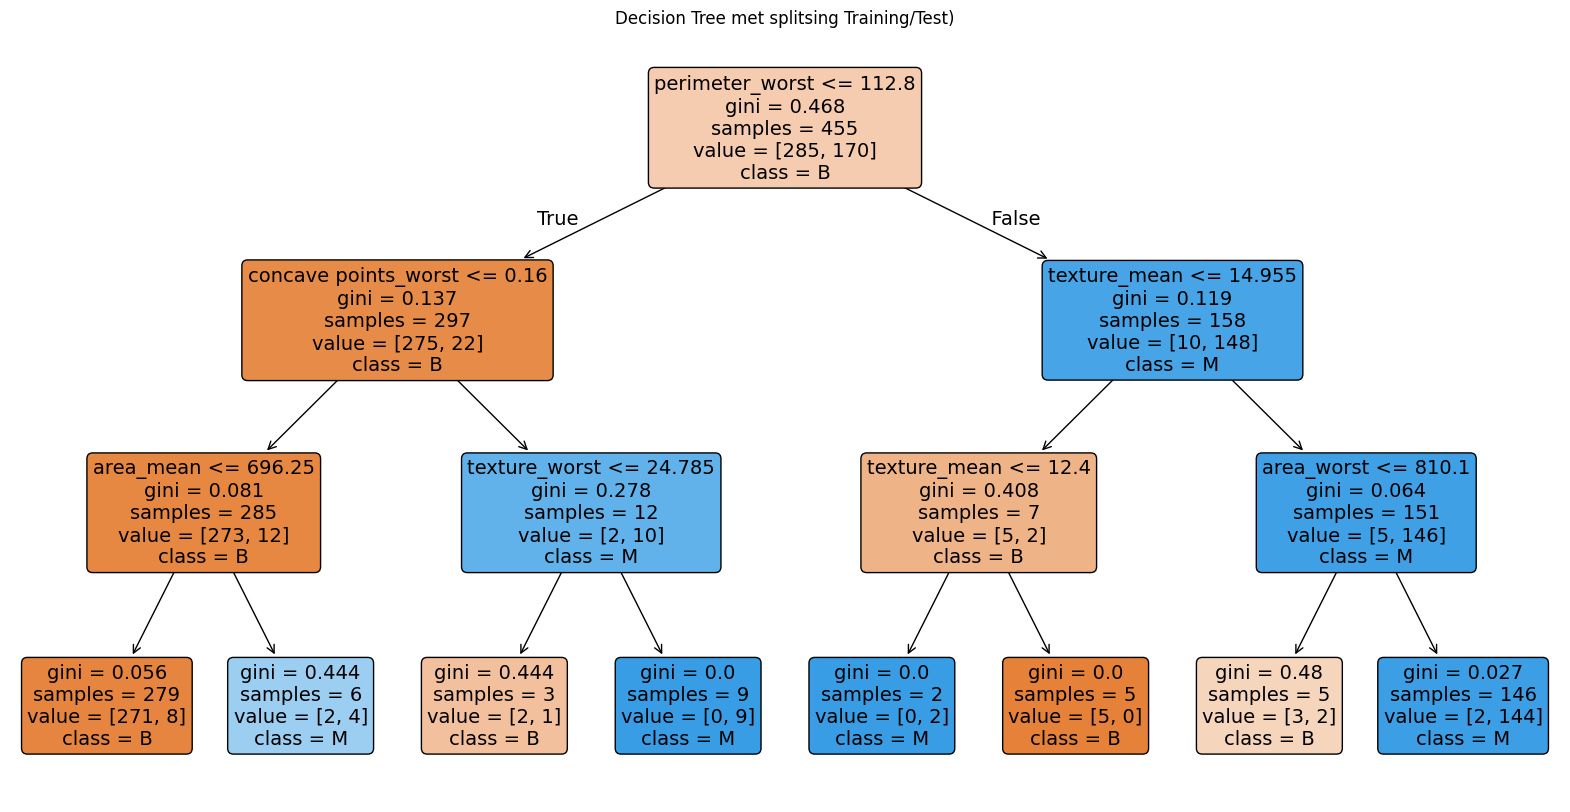

In [14]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

# 1. Splits de data in training (80%) en test (20%)
# Gebruik 'stratify' om de verhouding M/B gelijk te houden in beide sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Definieer en train het model op de trainingsset
dtree = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
dtree.fit(X_train, y_train)

# 3. Bereken de accuraatheid op de testset (de 'onbekende' data)
y_pred = dtree.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"De accuraatheid op nieuwe data is: {accuracy:.2%}")

# 4. Visualiseer de boom
plt.figure(figsize=(20,10))
plot_tree(
    dtree,
    feature_names=X.columns,
    class_names=['B', 'M'], # '0' en '1' vervangen door Benign/Malignant voor de leesbaarheid
    filled=True,
    rounded=True,
    fontsize=14
)
plt.title("Decision Tree met splitsing Training/Test)")
plt.show()

More realistic, with 90% accuracy.
The most important is understand the business cases (for ex. what is more important: miss false neg or false pos, in this case it is more imp not to classify M cells as B cells than otherwise: domain knowledge!)